### Example 2 for the usage of Rela²x. 
### See README.md for more information.

- Two ¹H nuclei.

- Dipole-dipole coupling.

- Rank $l = 2$.

Import Rela²x.

In [1]:
from rela2x import *

Define the spin system.

In [2]:
spin_system = ['1H', '1H']

Define the incoherent interactions.

In [3]:
dd_couplings = [[0, 1],
                [0, 0]]
intrs = {'DD': ('2', dd_couplings, [2])}

Compute the relaxation superoperator in the direct product basis of spherical tensor operators and create a RelaxationSuperoperator object.

In [4]:
R = R_object_in_prodop_basis(spin_system, intrs)


Computing R for interaction pairs...
DD12 * DD12
R computed.

Changing basis...
Basis changed.

Final clean-ups...
Done.


Display $R$ and visualize.

Matrix([
[0,                                                                                                         0,                                                                                                         0,                                     0,                                                               0,                                                               0,                                                                                                              0,                                                                                                              0,                                                                                                            0,                                                                                                            0,                                                                                                              0,                                                 

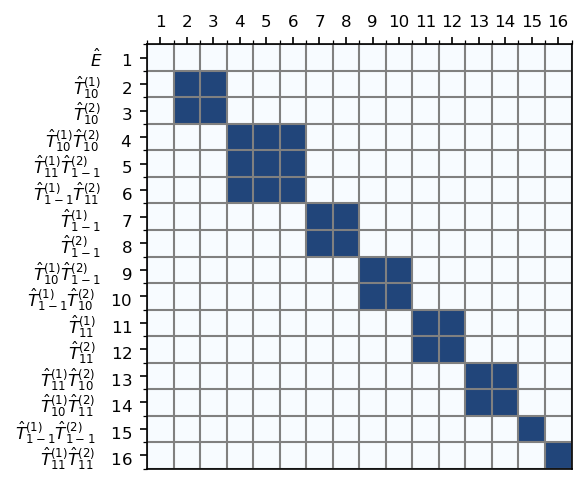

In [5]:
display(R.op)
R.visualize(basis_symbols=R.basis_symbols)

Check the auto-relaxation rate of $\hat T_{10}^{(1)}$, and the cross-relaxation rate between operators $\hat T_{10}^{(1)}$ and $\hat T_{10}^{(2)}$

In [6]:
rate1 = R.rate('110')
rate2 = R.rate('110', '210')

display(rate1)
display(rate2)

J^{DD12}_{(2, 0)}(0)/24 + J^{DD12}_{(2, 0)}(Abs(\omega_{1H}))/8 + J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))/4

-J^{DD12}_{(2, 0)}(0)/24 + J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))/4

Use isotropic rotational diffusion model.

In [7]:
R.to_isotropic_rotational_diffusion()
display(R.op)

Matrix([
[0,                                                                                                                                                                  0,                                                                                                                                                                  0,                                                              0,                                                                                               0,                                                                                               0,                                                                                                                                                                      0,                                                                                                                                                                      0,                                                                  

Check again the auto-relaxation rate of $\hat T_{10}^{(1)}$, and the cross-relaxation rate between operators $\hat T_{10}^{(1)}$ and $\hat T_{10}^{(2)}$

In [8]:
rate1 = R.rate('110')
rate2 = R.rate('110', '210')

display(rate1)
display(rate2)

\tau_c*G^{DD12}_{(2, 0)}(0)/12 + \tau_c*G^{DD12}_{(2, 0)}(0)/(2*(4*\omega_{1H}**2*\tau_c**2 + 1)) + \tau_c*G^{DD12}_{(2, 0)}(0)/(4*(\omega_{1H}**2*\tau_c**2 + 1))

-\tau_c*G^{DD12}_{(2, 0)}(0)/12 + \tau_c*G^{DD12}_{(2, 0)}(0)/(2*(4*\omega_{1H}**2*\tau_c**2 + 1))

Compute the (Solomon) equations of motion and save in LaTeX format.

(Remove the comment if you want to save the file)

In [9]:
eoms = equations_of_motion(R.op, R.basis_symbols, included_operators=[1, 2])
display(eoms)
# equations_of_motion_to_latex(eoms, 'dd_test')

Eq(Matrix([
[Derivative(\langle \hat{T}_{10}^{(1)}\rangle(t), t)],
[Derivative(\langle \hat{T}_{10}^{(2)}\rangle(t), t)]]), Matrix([
[(\tau_c*G^{DD12}_{(2, 0)}(0)/12 - \tau_c*G^{DD12}_{(2, 0)}(0)/(2*(4*\omega_{1H}**2*\tau_c**2 + 1)))*\langle \Delta \hat{T}_{10}^{(2)}\rangle(t) + (-\tau_c*G^{DD12}_{(2, 0)}(0)/12 - \tau_c*G^{DD12}_{(2, 0)}(0)/(2*(4*\omega_{1H}**2*\tau_c**2 + 1)) - \tau_c*G^{DD12}_{(2, 0)}(0)/(4*(\omega_{1H}**2*\tau_c**2 + 1)))*\langle \Delta \hat{T}_{10}^{(1)}\rangle(t)],
[(\tau_c*G^{DD12}_{(2, 0)}(0)/12 - \tau_c*G^{DD12}_{(2, 0)}(0)/(2*(4*\omega_{1H}**2*\tau_c**2 + 1)))*\langle \Delta \hat{T}_{10}^{(1)}\rangle(t) + (-\tau_c*G^{DD12}_{(2, 0)}(0)/12 - \tau_c*G^{DD12}_{(2, 0)}(0)/(2*(4*\omega_{1H}**2*\tau_c**2 + 1)) - \tau_c*G^{DD12}_{(2, 0)}(0)/(4*(\omega_{1H}**2*\tau_c**2 + 1)))*\langle \Delta \hat{T}_{10}^{(2)}\rangle(t)]]))

Do the same calculation but now using the quantum mechanical (Lindbladian) formalism of relaxation.


Computing R for interaction pairs...
DD12 * DD12
R computed.

Changing basis...
Basis changed.

Final clean-ups...
Done.


Matrix([
[                                                                                                                                                                                                                                                                                                   0,                                                                                                                                                                                                                                                                                                                           0,                                                                                                                                                                                                                                                                                                                           0,                                                               

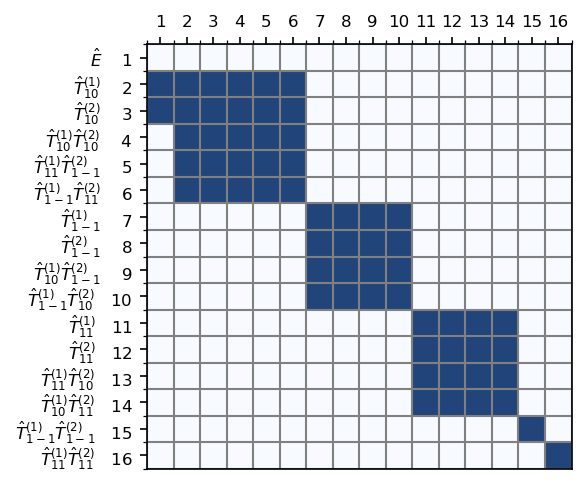

Eq(Matrix([
[Derivative(\langle \hat{T}_{10}^{(1)}\rangle(t), t)],
[Derivative(\langle \hat{T}_{10}^{(2)}\rangle(t), t)]]), Matrix([
[(J^{DD12}_{(2, 0)}(0)/24 - J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))*exp(\omega_{1H}*hbar/(T*k_B))/8 - J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))*exp(-\omega_{1H}*hbar/(T*k_B))/8)*\langle \hat{T}_{10}^{(2)}\rangle(t) + (-J^{DD12}_{(2, 0)}(0)/24 - J^{DD12}_{(2, 0)}(Abs(\omega_{1H}))*exp(\omega_{1H}*hbar/(2*T*k_B))/16 - J^{DD12}_{(2, 0)}(Abs(\omega_{1H}))*exp(-\omega_{1H}*hbar/(2*T*k_B))/16 - J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))*exp(\omega_{1H}*hbar/(T*k_B))/8 - J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))*exp(-\omega_{1H}*hbar/(T*k_B))/8)*\langle \hat{T}_{10}^{(1)}\rangle(t)],
[(J^{DD12}_{(2, 0)}(0)/24 - J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))*exp(\omega_{1H}*hbar/(T*k_B))/8 - J^{DD12}_{(2, 0)}(2*Abs(\omega_{1H}))*exp(-\omega_{1H}*hbar/(T*k_B))/8)*\langle \hat{T}_{10}^{(1)}\rangle(t) + (-J^{DD12}_{(2, 0)}(0)/24 - J^{DD12}_{(2, 0)}(Abs(\omega_{1H}))*exp(\omega_{1H}*hbar/(2

In [10]:
# Set quantum mechanical/Lindbladian relaxation theory
set_relaxation_theory('qm')

# Compute the relaxation superoperator in the direct product basis
R = R_object_in_prodop_basis(spin_system, intrs)

# Display and visualize
display(R.op)
R.visualize(basis_symbols=R.basis_symbols)

# Compute the equations of motion
eoms = equations_of_motion(R.op, R.basis_symbols, included_operators=[1, 2])
display(eoms)
# equations_of_motion_to_latex(eoms, 'dd_test')